In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Find the project root whether the kernel starts in the project folder or in notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Working folder:", Path.cwd())
print("Data folder:   ", DATA_DIR)
assert DATA_DIR.exists(), f"Data folder not found: {DATA_DIR}"

Working folder: E:\My Data Science Project\fraud-detection-streaming\notebooks
Data folder:    E:\My Data Science Project\fraud-detection-streaming\data\raw


In [2]:
def load_transactions(filename: str) -> pd.DataFrame:
    """Load a raw transactions CSV with correct data types."""
    return pd.read_csv(
        DATA_DIR / filename,
        index_col=0,                                    # first unnamed column = row number
        dtype={"cc_num": "string", "zip": "string"},    # IDs are text, not numbers
        parse_dates=["trans_date_trans_time", "dob"],   # read as real dates
    )

train = load_transactions("fraudTrain.csv")
test = load_transactions("fraudTest.csv")

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (1296675, 22)
Test:  (555719, 22)


In [3]:
train.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[us]
 1   cc_num                 1296675 non-null  string        
 2   merchant               1296675 non-null  str           
 3   category               1296675 non-null  str           
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  str           
 6   last                   1296675 non-null  str           
 7   gender                 1296675 non-null  str           
 8   street                 1296675 non-null  str           
 9   city                   1296675 non-null  str           
 10  state                  1296675 non-null  str           
 11  zip                    1296675 non-null  string        
 12  lat                    1296675 non-null

In [4]:
train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
counts = train["is_fraud"].value_counts()
fraud_rate = train["is_fraud"].mean()

print(counts)
print(f"\nFraud rate: {fraud_rate:.4%}")
print(f"Accuracy of a model that ALWAYS says 'not fraud': {1 - fraud_rate:.2%}")

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud rate: 0.5789%
Accuracy of a model that ALWAYS says 'not fraud': 99.42%


In [6]:
check = train[["trans_date_trans_time", "unix_time"]].head(3).copy()
check["unix_time_as_date"] = pd.to_datetime(check["unix_time"], unit="s")
check

,trans_date_trans_time,unix_time,unix_time_as_date
0,2019-01-01 00:00:18,1325376018,2012-01-01 00:00:18
1,2019-01-01 00:00:44,1325376044,2012-01-01 00:00:44
2,2019-01-01 00:00:51,1325376051,2012-01-01 00:00:51


In [7]:
share = train["merchant"].str.startswith("fraud_").mean()
print(f"Merchants starting with 'fraud_': {share:.2%}")

Merchants starting with 'fraud_': 100.00%


## Key findings so far

1. **Severe class imbalance:** 7,506 frauds out of 1,296,675 transactions (0.58%, about 1 in 173).
   A model that always predicts "not fraud" reaches 99.42% accuracy while catching zero fraud,
   so **accuracy is rejected as a metric**. We use PR-AUC and recall at a fixed false-positive rate.
2. **Inconsistent timestamps:** `unix_time` is offset by exactly 7 years from `trans_date_trans_time`
   (2012 vs 2019). **Decision:** use `trans_date_trans_time` as event time and drop `unix_time`.
3. **Misleading merchant prefix:** 100% of merchant names start with `fraud_`, so the prefix is a
   simulator artifact with no signal. **Decision:** strip it during cleaning.

In [8]:
train.groupby("is_fraud")["amt"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.67,154.01,1.00,9.61,47.28,82.54,28948.90
1,7506.0,531.32,390.56,1.06,245.66,396.50,900.88,1376.04


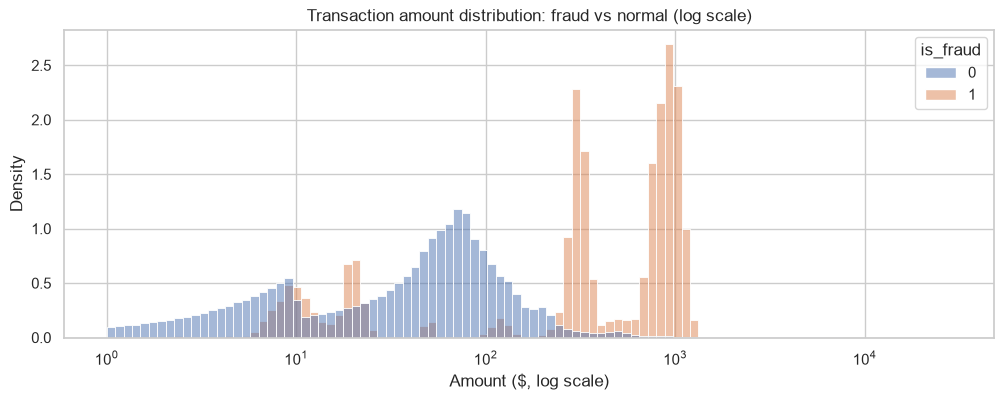

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(
    data=train, x="amt", hue="is_fraud",
    bins=100, log_scale=True,
    stat="density", common_norm=False, ax=ax,
)
ax.set_title("Transaction amount distribution: fraud vs normal (log scale)")
ax.set_xlabel("Amount ($, log scale)")
plt.show()

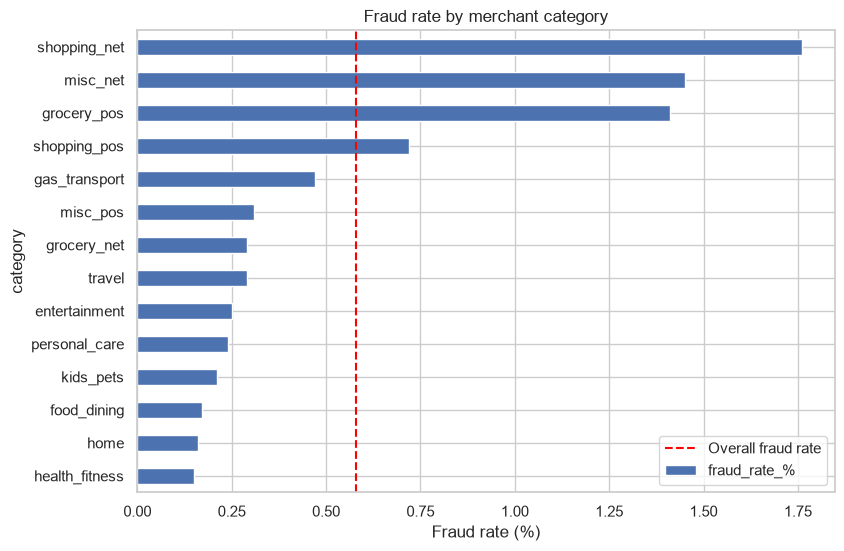

,transactions,fraud_rate,fraud_rate_%
category,,,
shopping_net,97543,0.017561,1.76
misc_net,63287,0.014458,1.45
grocery_pos,123638,0.014098,1.41
shopping_pos,116672,0.007225,0.72
gas_transport,131659,0.004694,0.47
misc_pos,79655,0.003139,0.31
grocery_net,45452,0.002948,0.29
travel,40507,0.002864,0.29
entertainment,94014,0.002478,0.25


In [10]:
cat_stats = (
    train.groupby("category")["is_fraud"]
    .agg(transactions="count", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)
cat_stats["fraud_rate_%"] = (cat_stats["fraud_rate"] * 100).round(2)

ax = cat_stats["fraud_rate_%"].plot(kind="barh", figsize=(9, 6))
ax.axvline(fraud_rate * 100, color="red", linestyle="--", label="Overall fraud rate")
ax.invert_yaxis()
ax.set_xlabel("Fraud rate (%)")
ax.set_title("Fraud rate by merchant category")
ax.legend()
plt.show()

cat_stats

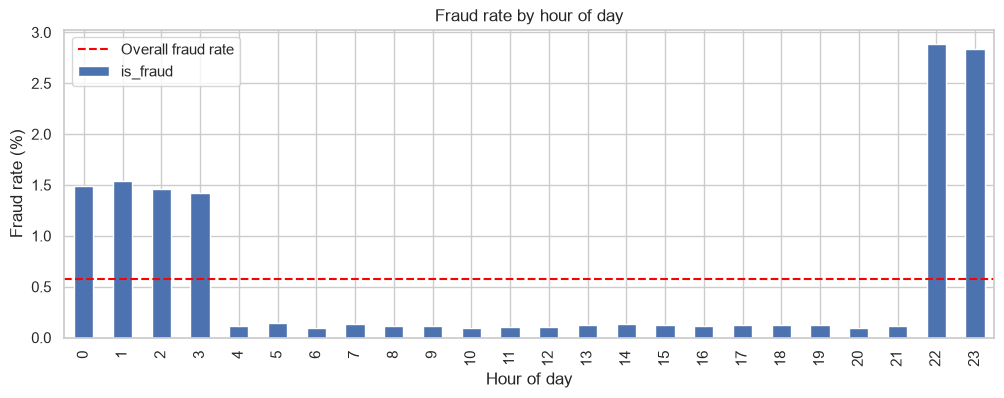

In [11]:
hour_rate = (
    train.groupby(train["trans_date_trans_time"].dt.hour)["is_fraud"].mean() * 100
)

ax = hour_rate.plot(kind="bar", figsize=(12, 4))
ax.axhline(fraud_rate * 100, color="red", linestyle="--", label="Overall fraud rate")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by hour of day")
ax.legend()
plt.show()

## Findings: amount, category and time

4. **Amount:** median fraud amount is ~$397 vs ~$47 for normal transactions (~8x).
   Fraud shows several distinct clusters, including very small amounts consistent with
   **card testing** (a small test purchase before larger ones), which motivates per-card
   sequence/velocity features.
   *Limitation:* no fraud exceeds ~$1,376 in this simulated data, so the model may learn
   "large amount = safe", which would not hold in real life.
5. **Category:** fraud rate varies ~10x across categories. Online categories
   (`shopping_net` 1.76%, `misc_net` 1.45%) and `grocery_pos` (1.41%) are highest;
   `food_dining`, `home`, `health_fitness` are lowest (~0.15%).
6. **Time of day:** fraud concentrates at night. Hours 22-23 reach ~2.8% and hours 0-3 ~1.5%,
   versus ~0.1% during the day, a 15-25x difference.

**Feature ideas for Phase 2:** `amt` (log-scaled), `category`, `hour`, `is_night`,
amount relative to the card's usual spending, and per-card transaction velocity.

In [12]:
cards = train.groupby("cc_num")["is_fraud"].agg(n_txn="count", n_fraud="sum")

print("Unique cards:              ", len(cards))
print("Cards with at least 1 fraud:", (cards["n_fraud"] > 0).sum())
print("\nFrauds per compromised card:")
print(cards.loc[cards["n_fraud"] > 0, "n_fraud"].describe().round(1))

Unique cards:               983
Cards with at least 1 fraud: 762

Frauds per compromised card:
count    762.0
mean       9.9
std        3.0
min        2.0
25%        8.0
50%       10.0
75%       12.0
max       19.0
Name: n_fraud, dtype: float64


In [13]:
fraud_tx = train[train["is_fraud"] == 1]
fraud_span = fraud_tx.groupby("cc_num")["trans_date_trans_time"].agg(lambda s: s.max() - s.min())

print("Time between first and last fraud on the same card:")
fraud_span.describe()

Time between first and last fraud on the same card:


count                       762
mean     1 days 16:29:42.633858
std      0 days 09:16:50.595879
min             0 days 00:59:39
25%      1 days 12:54:21.250000
50%      1 days 21:13:37.500000
75%      1 days 22:25:35.750000
max             2 days 21:19:26
Name: trans_date_trans_time, dtype: object

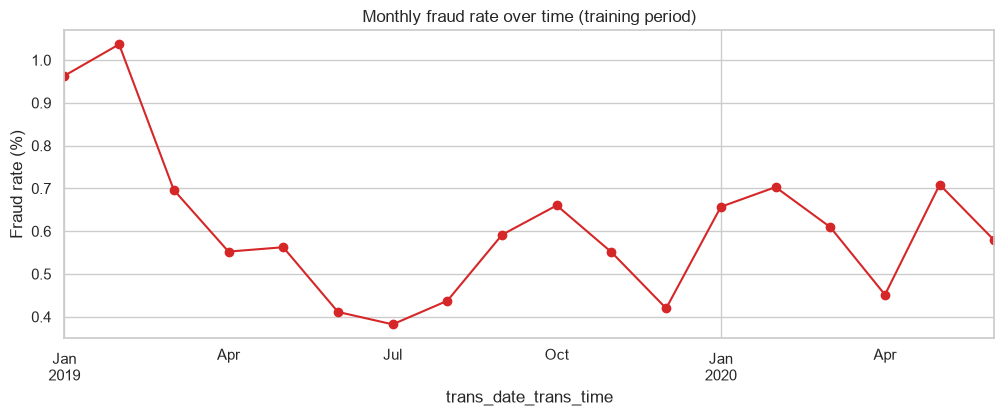

,count,mean,fraud_rate_%
trans_date_trans_time,,,
2019-01-01,52525,0.009634,0.963351
2019-02-01,49866,0.010368,1.036779
2019-03-01,70939,0.006964,0.696373
2019-04-01,68078,0.005523,0.552308
2019-05-01,72532,0.005625,0.562510
2019-06-01,86064,0.004113,0.411322
2019-07-01,86596,0.003822,0.382235
2019-08-01,87359,0.004373,0.437276
2019-09-01,70652,0.005916,0.591632


In [14]:
monthly = (
    train.set_index("trans_date_trans_time")
    .resample("MS")["is_fraud"]
    .agg(["count", "mean"])
)
monthly["fraud_rate_%"] = monthly["mean"] * 100

fig, ax1 = plt.subplots(figsize=(12, 4))
monthly["fraud_rate_%"].plot(ax=ax1, marker="o", color="tab:red")
ax1.set_ylabel("Fraud rate (%)")
ax1.set_title("Monthly fraud rate over time (training period)")
plt.show()

monthly